## Making a free Account on SerpAPI to get Flight Prices:

1. Go to SerpApi.com and create a free account.

2. Go to your dashboard and copy your API Key.

In [1]:
# Testing SerpAPI Connection:

import os
from http.client import responses

import requests
from dotenv import load_dotenv
load_dotenv(override= True)
flight_api_key = os.getenv('FLIGHT_API_KEY')

def get_live_price(origin_iata, destination_iata, outbound_date):

    print(f'Fetching live prices for {origin_iata} to {destination_iata}...')

    url = 'https://serpapi.com/search'

    params = {
        'engine': 'google_flights',
        'departure_id': origin_iata,
        'arrival_id': destination_iata,
        'outbound_date': outbound_date, #YYYY-MM-DD
        'type': 2,
        'currency': 'USD',
        'hl': 'en',
        'api_key': flight_api_key
    }

    response = requests.get(url, params=params)
    data = response.json()
    #print(data)

    # Extracting just the price of first 'best flight':
    try:
        best_flight = data['best_flights'][0]
        price = best_flight['price']
        airline = best_flight['flights'][0]['airline']
        return f'The cheapest live flight is ${price} on {airline}.'

    except KeyError:
        return 'Could not find flight data. Check your dates or IATA codes.'

# Testing:
print(get_live_price('JFK', 'LHR', '2026-03-30'))

Fetching live prices for JFK to LHR...
The cheapest live flight is $395 on British Airways.


## Chat Interface:

In [2]:
# Imports:

import gradio as gr
import os
from dotenv import load_dotenv
from openai import OpenAI
from datetime import datetime
import json

In [3]:
# LLM API Connection:

MODEL = 'gpt-4.1-mini'
api_key = os.getenv('OPENAI_API_KEY')

openai = OpenAI()

In [4]:
# System Prompt:

today_date = datetime.now()

system_prompt= f'''
You are a helpful assistant for an Airline called FlightAI.
Today's date is {today_date}.
Give short, courteous answers.
If a user asks for a flight, use your tool to check live prices.
Always convert city names to 3-letter IATA airport codes before calling the tool.
'''

In [5]:
# Function to Get Ticket Price:
def get_live_price(origin_iata, destination_iata, outbound_date):

    print(f'Fetching live prices for {origin_iata} to {destination_iata}...')

    url = 'https://serpapi.com/search'

    params = {
        'engine': 'google_flights',
        'departure_id': origin_iata,
        'arrival_id': destination_iata,
        'outbound_date': outbound_date, #YYYY-MM-DD
        'type': 2,
        'currency': 'INR',
        'hl': 'en',
        'api_key': flight_api_key
    }

    response = requests.get(url, params=params)
    data = response.json()
    #print(data)

    # Extracting just the price of first 'best flight':
    try:
        best_flight = data['best_flights'][0]
        price = best_flight['price']
        airline = best_flight['flights'][0]['airline']
        return f'The cheapest live flight is {price} INR on {airline}.'

    except KeyError:
        return 'Could not find flight data. Check your dates or IATA codes.'

In [6]:
get_live_price('BOM', 'LHR', '2026-03-30')

Fetching live prices for BOM to LHR...


'The cheapest live flight is 141049 INR on IndiGo.'

In [7]:
# Defining JSON Function Descriptions for LLM:

get_ticket_price_schema = {
    'name': 'get_live_price',
    'description': 'Get the REAL-TIME live ticket price for a one-way flight.',
    'parameters': {
        'type': 'object',
        'properties': {
            'origin_iata': {'type': 'string',
                            'description': 'The 3-letter IATA airport code for the origin city.'},
            'destination_iata': {'type': 'string',
                                 'description': 'The 3-letter IATA airport code for the destination city.'},
            'outbound_date': {'type': 'string',
                              'description': 'The date of the flight in exact YYYY-MM-DD format.'}
        },
        'required': ['origin_iata', 'destination_iata', 'outbound_date'],
        'additionalProperties': False
    }
}

In [8]:
# Adding function to main Tool List:
tools = [
    {'type': 'function', 'function': get_ticket_price_schema}
]

In [9]:
# Defining Function to Handle Tool Call:

def handle_tool_calls(message):
    """
    Acts as a router. Reads the tool calls requested by the LLM,
    executes the corresponding Python functions, and returns the results.
    :param message: Message from LLM requesting tool call.
    :return: Response from Get Ticket Price Function.
    """

    responses = []

    for tool_call in message.tool_calls:

        # Extracting Arguments:
        arguments = json.loads(tool_call.function.arguments)

        # Get Ticket Price:
        if tool_call.function.name == 'get_live_price':
            origin_iata = arguments.get('origin_iata')
            destination_iata = arguments.get('destination_iata')
            outbound_date = arguments.get('outbound_date')

            # Getting Ticket Price:
            price_details = get_live_price(origin_iata, destination_iata, outbound_date)

            # Response:
            responses.append({
                'role': 'tool',
                'content': price_details,
                'tool_call_id': tool_call.id,
            })

    return responses

In [10]:
# Defining Callback Function:

def chat(message, history):
    """
    The main conversational loop. Handles formatting history, triggering the LLM, and managing the 'Pause and Request' tool-calling cycle.

    :param message: Current Message from LLM
    :param history: Chat history
    :return: LLM Response
    """

    # Formatting the History:
    history = [{'role': h['role'], 'content': h['content']} for h in history]

    # Messages:
    messages = [{'role': 'system', 'content': system_prompt}] + history + [{'role': 'user', 'content': message}]

    # Call to LLM:
    response = openai.chat.completions.create(model= MODEL,
                                              messages=messages,
                                              tools= tools)

    # The Loop: Keep running tools as long as the LLM asks for them
    while response.choices[0].finish_reason == 'tool_calls':
        # Grabbing the tool request message:
        message_obj = response.choices[0].message

        # Handle Tool Calls:
        tool_responses = handle_tool_calls(message_obj)

        # Adding both the message and tool's response to history:
        messages.append(message_obj)
        messages.extend(tool_responses)

        # Calling LLM again with Updated Messages:
        response = openai.chat.completions.create(model= MODEL,
                                                  messages= messages,
                                                  tools= tools)

    return response.choices[0].message.content

In [11]:
# Gradio Interface:

gr.ChatInterface(fn= chat).launch(inbrowser= True)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Fetching live prices for AMD to BLR...


## Going Multi-Modal:

We can use DALL-E-3, the image generation model behind GPT-4o, to make us some images

Let's put this in a function called artist.

`Price alert: each time I generate an image it costs about 4 cents.`

In [12]:
# Some Imports:

import base64
from io import BytesIO
from PIL import Image

In [13]:
def artist(city):

    image_response = openai.images.generate(
        model= 'dall-e-3',
        prompt= f'An image representing a vacation in {city}, showing tourist spots and everything unique about {city}, in a vibrant pop-art style',
        size= '1024x1024',
        n= 1,
        response_format= 'b64_json'
    )

    image_base64 = image_response.data[0].b64_json
    image_data = base64.b64decode(image_base64)
    return Image.open(BytesIO(image_data))

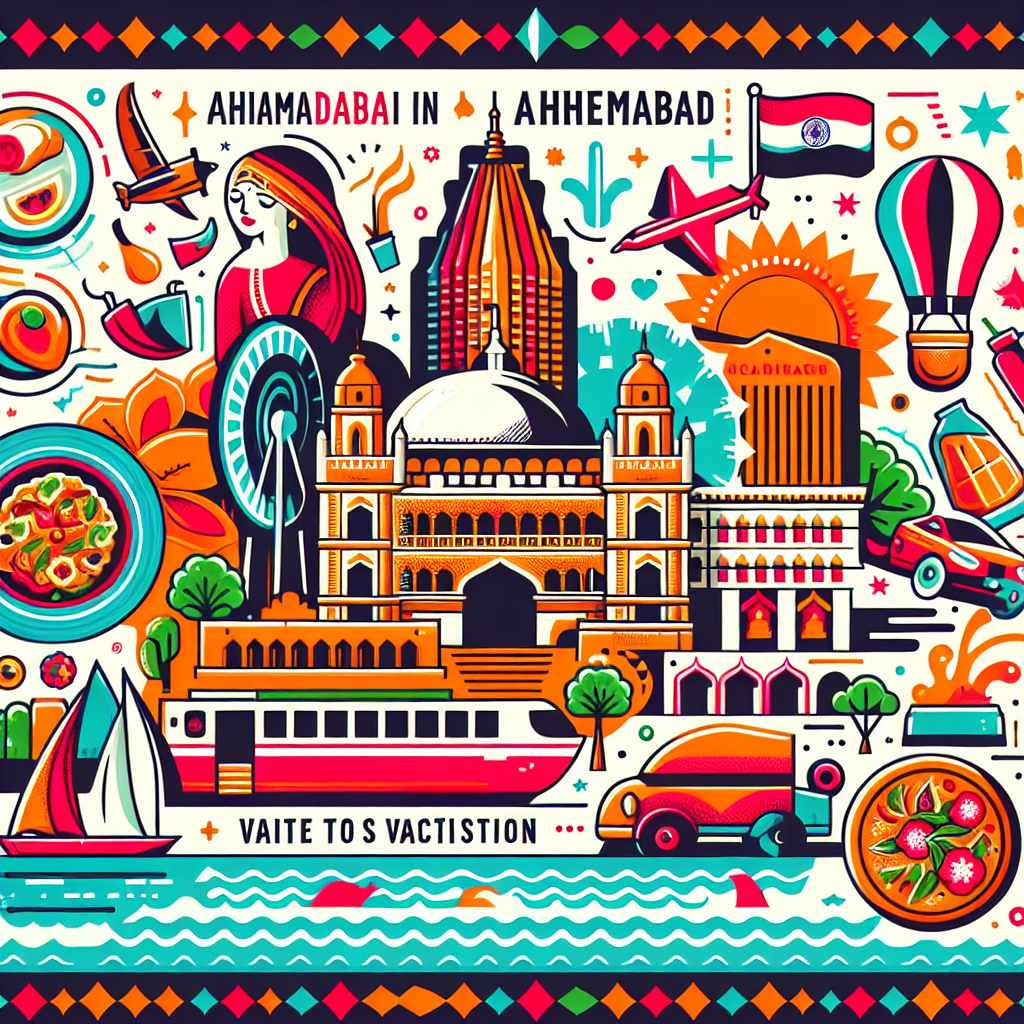

In [14]:
# Testing Image Generation:
image = artist('Ahmedabad')
display(image)

In [15]:
# Function to Generate Audio:
def talker(message):
    response = openai.audio.speech.create(
        model= 'gpt-4o-mini-tts',
        voice= 'alloy', # 'onyx', 'coral'
        input= message
    )

    return  response.content

## Multi-Modal AI Assistant with Image and Audio Generation:

In [16]:
# Defining Callback Function:

def chat(history):

    history = [{'role': h['role'], 'content': h['content']} for h in history]

    messages = [{'role': 'system', 'content': system_prompt}] + history

    response = openai.chat.completions.create(model= MODEL,
                                              messages= messages,
                                              tools= tools)

    cities = []
    image = None

    while response.choices[0].finish_reason == 'tool_calls':
        message_obj = response.choices[0].message
        responses, cities = handle_tool_calls_and_return_cities(message_obj)
        messages.append(message_obj)
        messages.extend(responses)

        response = openai.chat.completions.create(model= MODEL,
                                                  messages= messages,
                                                  tools= tools)

    reply = response.choices[0].message.content
    history += [{'role': 'assistant', 'content': reply}]

    voice = talker(reply)

    if cities:
        image = artist(cities[0])

    return history, voice, image

In [17]:
# Handling Tool Calls:

def handle_tool_calls_and_return_cities(message):

    responses = []
    cities = []

    for tool_call in message.tool_calls:
        if tool_call.function.name == 'get_live_price':
            arguments = json.loads(tool_call.function.arguments)
            origin = arguments.get('origin_iata')
            destination = arguments.get('destination_iata')
            date = arguments.get('outbound_date')
            cities.append(destination)
            price_details = get_live_price(origin, destination, date)
            responses.append({
                'role': 'tool',
                'content': price_details,
                'tool_call_id': tool_call.id,
            })

    return responses, cities

## The 3 types of Gradio UI

`gr.Interface` is for standard, simple UIs

`gr.ChatInterface` is for standard ChatBot UIs

`gr.Blocks` is for custom UIs where you control the components and the callbacks

In [18]:
# Callbacks (along with the chat() function above)

def put_message_in_chatbot(message, history):
        return '', history + [{'role':'user', 'content':message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500)
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label= 'Chat with our AI Assistant:')

# Hooking up events to callbacks

    message.submit(put_message_in_chatbot, inputs=[message, chatbot], outputs=[message, chatbot]).then(
        chat, inputs=chatbot, outputs=[chatbot, audio_output, image_output]
    )

ui.launch(inbrowser=True)

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


Fetching live prices for AMD to BLR...
